In [ ]:
import os
import gdown

# Folder ID
folder_id = '1z-NRFtqB-cn7oqwi2v3ZP-ADwYN6F1Mt'

# Download folder structure
def download_drive_folder(fid, destination):
    os.makedirs(destination, exist_ok=True)
    # gdown
    url = f'https://drive.google.com/drive/folders/{fid}'
    gdown.download_folder(url, output=destination, quiet=False, use_cookies=False)

print("Downloading data from Google Drive...")
try:
    # Downloading into a temporary folder then moving if necessary,
    # but here we target the base_dir directly
    gdown.download_folder(id=folder_id, output='data_files', quiet=False)
    print("\nDownload complete. Current structure:")
    for root, dirs, files in os.walk('data_files'):
        level = root.replace('data_files', '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f"{subindent}{f}")
except Exception as e:
    print(f"An error occurred: {e}")
    print("If the folder download fails, please ensure the Drive link is set to 'Anyone with the link can view'.")

Retrieving folder contents


Retrieving folder 1nnyB2-Ae5cCbPT2DQR8dd6_CdaFM2TdK Group_A
Processing file 1Nr5wxVRG--mPQqv-X2nbueYD58U0ZvPy customers.csv
Processing file 16iiaUIlHy5R4_pcZzltcK2t-ROY1blAw geography.csv
Processing file 1VlEN8leItj5hUidWokt-TzXE4tELMR67 inventory.csv
Processing file 1M7IZC95Nu9lPIumMQzUHvevOYO_18qgR order_items.csv
Processing file 1CYjCqUCB96d5D21ot4pzXWzgsuPxU96A orders.csv
Processing file 1D_fL0MfJQo49GXugaxWM8QwbSVCj_vuH payments.csv
Processing file 1_duMrfIngYmQLOK48T6cgHK2j5qW5MOr products.csv
Processing file 1VLx5LCf_p_CqVRUxx5psR92hdLpegq5w promotions.csv
Processing file 1_lk6_qDg1mAyuivwBxWhmweVowrBUd97 returns.csv
Processing file 1lRtSd8mMHfp0S6DeRODYck5Nu3SM_F7n reviews.csv
Processing file 1SelF-sStmZgKuzby9YfFJ1gtGV4gmeU8 sales.csv
Processing file 1hm7inUf6PEQCvMyyU0l5Cq4G7FRIJIPX shipments.csv
Processing file 179w4w7W8plljzElwJjQ5hGJzJ6mszBqT web_traffic.csv
Retrieving folder 169nsCFYeX6iNqR2w9z2k-D4mDtAi9fyY Group_B
Processing file 17b-gRg79XSItdJEwhtS5ol6aWJV_06Ky custom

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Nr5wxVRG--mPQqv-X2nbueYD58U0ZvPy
To: /content/data_files/Group_A/customers.csv
100%|██████████| 7.08M/7.08M [00:00<00:00, 76.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=16iiaUIlHy5R4_pcZzltcK2t-ROY1blAw
To: /content/data_files/Group_A/geography.csv
100%|██████████| 1.40M/1.40M [00:00<00:00, 49.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VlEN8leItj5hUidWokt-TzXE4tELMR67
To: /content/data_files/Group_A/inventory.csv
100%|██████████| 3.29M/3.29M [00:00<00:00, 122MB/s]
Downloading...
From: https://drive.google.com/uc?id=1M7IZC95Nu9lPIumMQzUHvevOYO_18qgR
To: /content/data_files/Group_A/order_items.csv
100%|██████████| 17.6M/17.6M [00:00<00:00, 51.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CYjCqUCB96d5D21ot4pzXWzgsuPxU96A
To: /content/data_files/Group_A/orders.csv
100%|██████████| 33.7M/33


Download complete. Current structure:
data_files/
    Group_A/
        web_traffic.csv
        products.csv
        orders.csv
        shipments.csv
        sales.csv
        payments.csv
        reviews.csv
        promotions.csv
        order_items.csv
        customers.csv
        geography.csv
        inventory.csv
        returns.csv
    Group_B/
        web_traffic.csv
        products.csv
        orders.csv
        shipments.csv
        sales.csv
        payments.csv
        reviews.csv
        promotions.csv
        order_items.csv
        customers.csv
        geography.csv
        inventory.csv
        returns.csv



Download completed


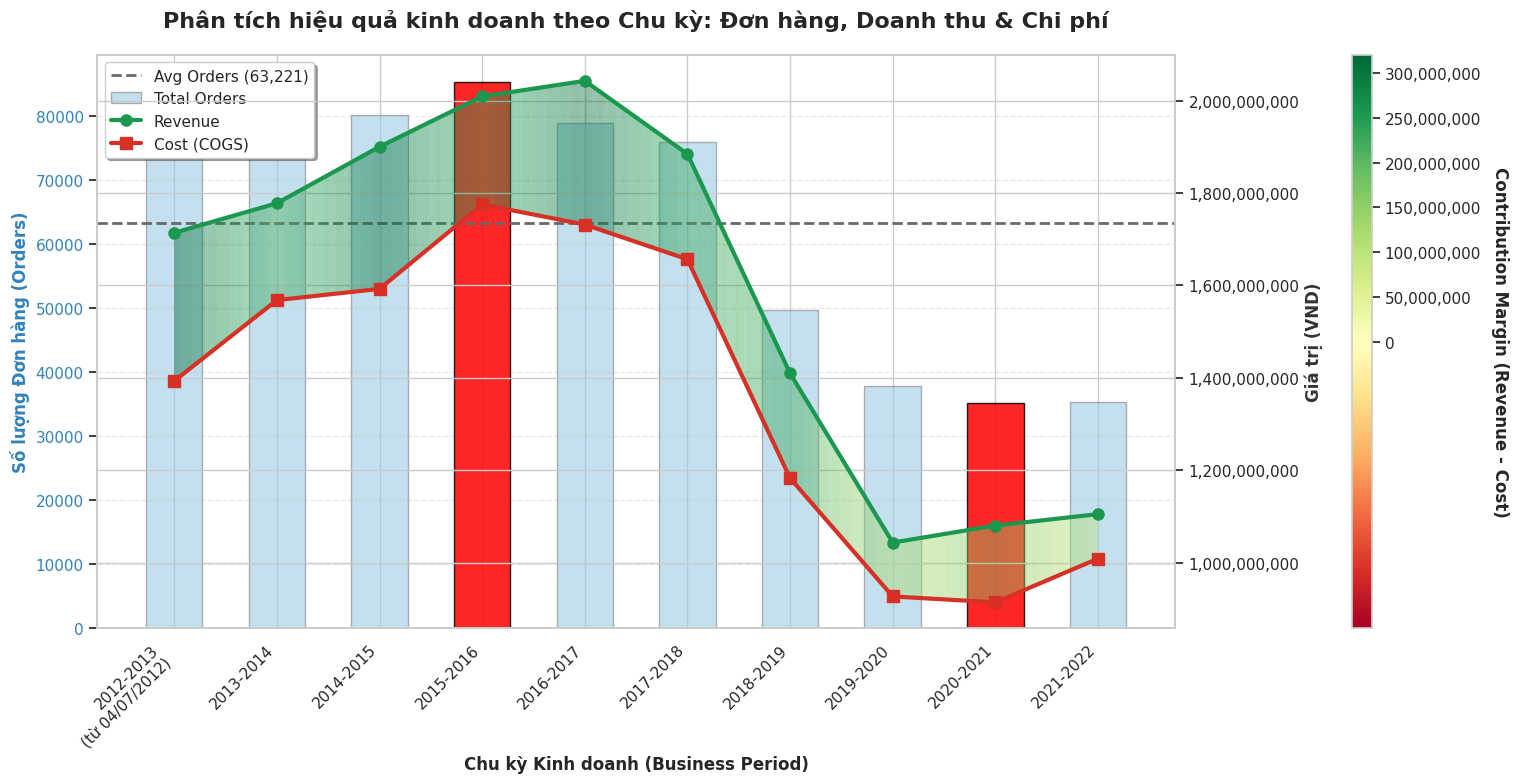

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
import os

# 1. Cấu hình đường dẫn dữ liệu cho Colab
base_dir = 'data_files'
groups = ['Group_A', 'Group_B']

all_sales = []
all_orders = []

for group in groups:
    sales_path = os.path.join(base_dir, group, 'sales.csv')
    orders_path = os.path.join(base_dir, group, 'orders.csv')

    if os.path.exists(sales_path):
        all_sales.append(pd.read_csv(sales_path))
    if os.path.exists(orders_path):
        all_orders.append(pd.read_csv(orders_path))

df_sales = pd.concat(all_sales)
df_orders = pd.concat(all_orders)

# 2. Tiền xử lý dữ liệu - CUSTOM BUSINESS PERIOD
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Tạo các mốc thời gian (bins)
date_bins = [pd.to_datetime(f'{year}-07-04') for year in range(2012, 2022)]
date_bins.append(pd.to_datetime('2022-07-05'))
date_bins.append(pd.to_datetime('2030-01-01'))

# Tạo nhãn (labels) cho từng chu kỳ và THÊM GHI CHÚ THỜI GIAN
period_labels = [f"{year}-{year+1}" for year in range(2012, 2022)]
period_labels[0] = "2012-2013\n(từ 04/07/2012)"
period_labels.append("Latest\n(từ 05/07/2022 đến 31/12/2022)")

# Phân loại dữ liệu
df_sales['Period'] = pd.cut(df_sales['Date'], bins=date_bins, labels=period_labels, right=False)
df_orders['Period'] = pd.cut(df_orders['order_date'], bins=date_bins, labels=period_labels, right=False)

df_sales = df_sales.dropna(subset=['Period'])
df_orders = df_orders.dropna(subset=['Period'])

# Gom nhóm theo Chu kỳ
yearly_sales = df_sales.groupby('Period', observed=True)[['Revenue', 'COGS']].sum().reset_index()
yearly_orders = df_orders.groupby('Period', observed=True)['order_id'].nunique().reset_index()
yearly_orders.rename(columns={'order_id': 'Total_Orders'}, inplace=True)

df_yearly = pd.merge(yearly_sales, yearly_orders, on='Period', how='inner')

# 3. Thiết lập tham số vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(16, 8))
x = np.arange(len(df_yearly['Period']))

# BAR CHART
bars_orders = ax1.bar(x, df_yearly['Total_Orders'], width=0.55, label='Total Orders', color='#9ecae1', alpha=0.6, edgecolor='grey')

df_valid = df_yearly.iloc[:-1]
max_order = df_valid['Total_Orders'].max()
min_order = df_valid['Total_Orders'].min()
avg_order = df_yearly['Total_Orders'].mean()

for i, bar in enumerate(bars_orders):
    if i != len(bars_orders) - 1:
        if bar.get_height() == max_order or bar.get_height() == min_order:
            bar.set_color('red')
            bar.set_alpha(0.85)
            bar.set_edgecolor('black')

ax1.axhline(y=avg_order, color='dimgrey', linestyle='--', linewidth=2, label=f'Avg Orders ({avg_order:,.0f})')
ax1.set_xlabel('Chu kỳ Kinh doanh (Business Period)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Số lượng Đơn hàng (Orders)', fontsize=12, fontweight='bold', color='#3182bd')
ax1.tick_params(axis='y', labelcolor='#3182bd')
ax1.set_xticks(x)
ax1.set_xticklabels(df_yearly['Period'], rotation=45, ha='right')

# LINE CHART
ax2 = ax1.twinx()
line_rev = ax2.plot(x, df_yearly['Revenue'], color='#1a9850', marker='o', markersize=8, linewidth=3, label='Revenue')
line_cogs = ax2.plot(x, df_yearly['COGS'], color='#d73027', marker='s', markersize=8, linewidth=3, label='Cost (COGS)')

# GRADIENT FILL
x_dense = np.linspace(x.min(), x.max(), 500)
rev_dense = np.interp(x_dense, x, df_yearly['Revenue'])
cogs_dense = np.interp(x_dense, x, df_yearly['COGS'])
diff_dense = rev_dense - cogs_dense

vmin, vmax = diff_dense.min(), diff_dense.max()
if vmin >= 0: vmin = -vmax * 0.1
if vmax <= 0: vmax = -vmin * 0.1

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.cm.RdYlGn

for i in range(len(x_dense) - 1):
    color = cmap(norm(diff_dense[i]))
    ax2.fill_between([x_dense[i], x_dense[i+1]], [rev_dense[i], rev_dense[i+1]], [cogs_dense[i], cogs_dense[i+1]], color=color, alpha=0.45, edgecolor="none")

ax2.set_ylabel('Giá trị (VND)', fontsize=12, fontweight='bold', color='#333333')
formatter = ticker.FuncFormatter(lambda y, pos: f'{y:,.0f}')
ax2.yaxis.set_major_formatter(formatter)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2, pad=0.12, aspect=30)
cbar.set_label('Contribution Margin (Revenue - Cost)', rotation=270, labelpad=20, fontweight='bold')
cbar.ax.yaxis.set_major_formatter(formatter)

plt.title('Phân tích hiệu quả kinh doanh theo Chu kỳ: Đơn hàng, Doanh thu & Chi phí', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

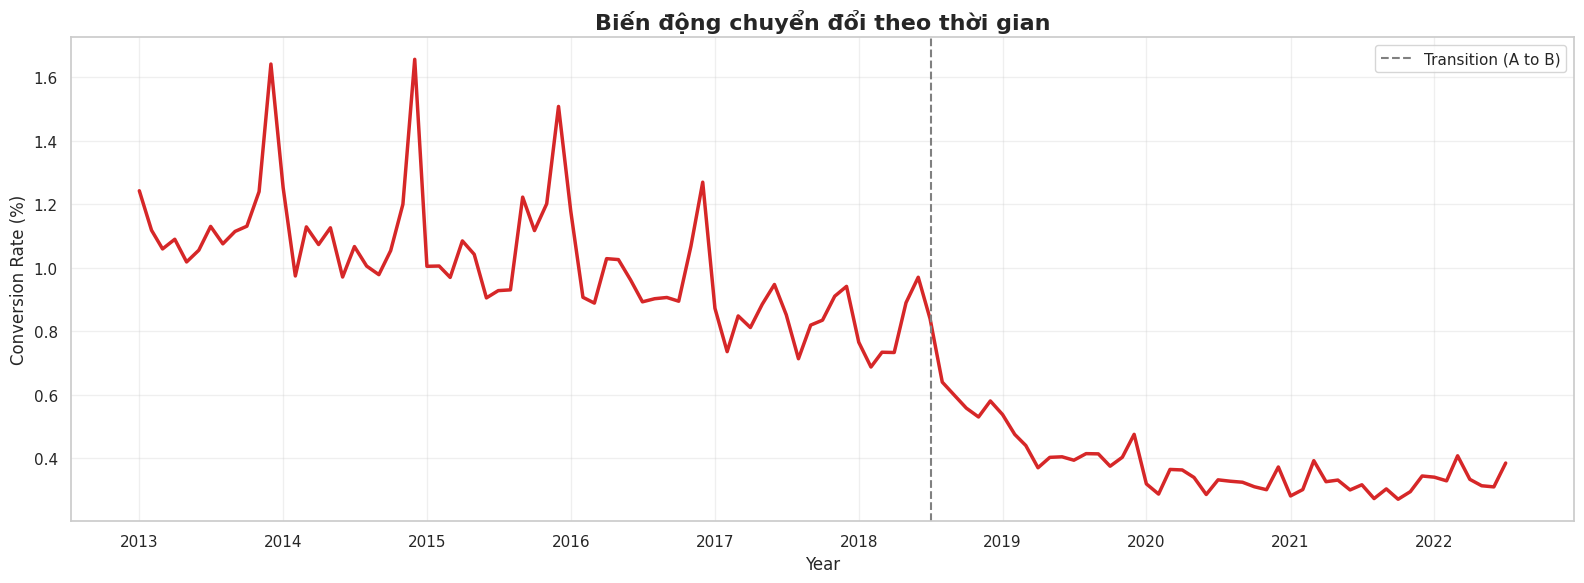

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load data from both groups to get a full timeline
base_dir = 'data_files'
groups = ['Group_A', 'Group_B']

all_traffic = []
all_orders = []

for group in groups:
    traffic_path = os.path.join(base_dir, group, 'web_traffic.csv')
    orders_path = os.path.join(base_dir, group, 'orders.csv')

    if os.path.exists(traffic_path):
        df_t = pd.read_csv(traffic_path)
        all_traffic.append(df_t)
    if os.path.exists(orders_path):
        df_o = pd.read_csv(orders_path)
        all_orders.append(df_o)

# Concatenate and prepare dates
df_traffic_total = pd.concat(all_traffic).rename(columns={'date': 'Date'})
df_orders_total = pd.concat(all_orders).rename(columns={'order_date': 'Date'})

df_traffic_total['Date'] = pd.to_datetime(df_traffic_total['Date'])
df_orders_total['Date'] = pd.to_datetime(df_orders_total['Date'])

# 2. Aggregate by month to smooth out daily noise
daily_traffic = df_traffic_total.groupby('Date')['sessions'].sum().reset_index()
daily_orders = df_orders_total.groupby('Date')['order_id'].nunique().reset_index()

# Merge and calculate CR
df_cr = pd.merge(daily_traffic, daily_orders, on='Date', how='left').fillna(0)
df_cr['Month'] = df_cr['Date'].dt.to_period('M')

monthly_cr = df_cr.groupby('Month').agg({'sessions': 'sum', 'order_id': 'sum'}).reset_index()
monthly_cr['Conversion Rate (%)'] = (monthly_cr['order_id'] / monthly_cr['sessions']) * 100
monthly_cr['Month_Timestamp'] = monthly_cr['Month'].dt.to_timestamp()

# 3. Visualization
plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_cr, x='Month_Timestamp', y='Conversion Rate (%)', color='#d62728', linewidth=2.5)

plt.axvline(pd.Timestamp('2018-07-04'), color='grey', linestyle='--', label='Transition (A to B)')
plt.title('Biến động chuyển đổi theo thời gian', fontsize=16, fontweight='bold')
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Đang tính toán Benchmark từ Group A...
Đang tính toán Opportunities & Risks cho Group B...


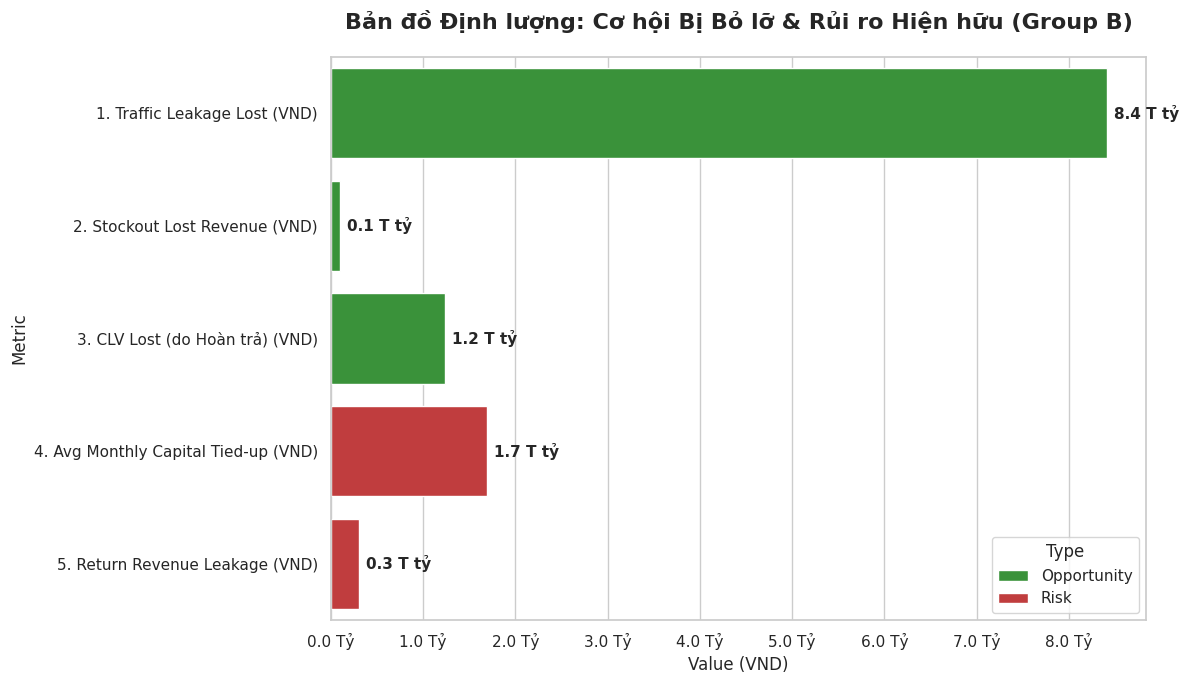

In [ ]:
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

# 1. Cấu hình đường dẫn cho Colab
base_dir = 'data_files'
dir_A = os.path.join(base_dir, "Group_A")
dir_B = os.path.join(base_dir, "Group_B")

def calculate_opportunities_and_risks(group_dir, group_name, benchmark_cr=None, avg_freq_benchmark=None):
    try:
        # Load data
        orders = pd.read_csv(os.path.join(group_dir, 'orders.csv'))
        sales = pd.read_csv(os.path.join(group_dir, 'sales.csv'))
        order_items = pd.read_csv(os.path.join(group_dir, 'order_items.csv'), low_memory=False)
        traffic = pd.read_csv(os.path.join(group_dir, 'web_traffic.csv'))
        inventory = pd.read_csv(os.path.join(group_dir, 'inventory.csv'))
        returns = pd.read_csv(os.path.join(group_dir, 'returns.csv'))
        products = pd.read_csv(os.path.join(group_dir, 'products.csv'))

        # Chuẩn bị Metrics nền tảng
        total_sessions = traffic['sessions'].sum()
        total_orders = orders['order_id'].nunique()
        total_revenue = sales['Revenue'].sum()
        aov = total_revenue / total_orders if total_orders > 0 else 0
        current_cr = (total_orders / total_sessions) if total_sessions > 0 else 0

        delivered_orders = orders[orders['order_status'].isin(['delivered', 'returned'])]['order_id'].nunique()
        returned_orders = returns['order_id'].nunique()
        return_rate = returned_orders / delivered_orders if delivered_orders > 0 else 0

        # 1. Traffic Leakage (Chi phí rớt phễu)
        traffic_leakage_lost = 0
        if benchmark_cr is not None and current_cr < benchmark_cr:
            traffic_leakage_lost = (benchmark_cr - current_cr) * total_sessions * aov

        # 2. Inventory Stockout (Doanh thu lỡ mất do hết hàng)
        inv_prod = pd.merge(inventory, products[['product_id', 'price']], on='product_id', how='left')
        valid_stockout = inv_prod[(inv_prod['stockout_days'] > 0) & (inv_prod['stockout_days'] < 30)].copy()
        valid_stockout['lost_revenue'] = (valid_stockout['units_sold'] / (30 - valid_stockout['stockout_days'])) * valid_stockout['stockout_days'] * valid_stockout['price']
        stockout_lost_revenue = valid_stockout['lost_revenue'].sum()

        # 3. CLV Opportunity Lost
        returns_with_customer = pd.merge(returns, orders[['order_id', 'customer_id']], on='order_id', how='left')
        num_customers_returned = returns_with_customer['customer_id'].nunique()
        clv_lost_revenue = 0
        if avg_freq_benchmark is not None:
            clv_lost_revenue = num_customers_returned * aov * avg_freq_benchmark

        # 4. Capital Tied-up Cost (Overstock)
        safe_days = 30
        inv_prod_cost = pd.merge(inventory, products[['product_id', 'cogs']], on='product_id', how='left')
        inv_prod_cost['safe_inventory'] = (inv_prod_cost['units_sold'] / 30) * safe_days
        inv_prod_cost['overstock_units'] = (inv_prod_cost['stock_on_hand'] - inv_prod_cost['safe_inventory']).clip(lower=0)
        inv_prod_cost['capital_tied_up'] = inv_prod_cost['overstock_units'] * inv_prod_cost['cogs']
        avg_monthly_capital_tied_up = inv_prod_cost['capital_tied_up'].sum() / inv_prod_cost['month'].nunique() if inv_prod_cost['month'].nunique() > 0 else 0

        # 5. Return Revenue Leakage
        return_revenue_leakage = total_revenue * return_rate

        return {
            'Group': group_name,
            'Current CR': current_cr,
            '1. Traffic Leakage Lost (VND)': traffic_leakage_lost,
            '2. Stockout Lost Revenue (VND)': stockout_lost_revenue,
            '3. CLV Lost (do Hoàn trả) (VND)': clv_lost_revenue,
            '4. Avg Monthly Capital Tied-up (VND)': avg_monthly_capital_tied_up,
            '5. Return Revenue Leakage (VND)': return_revenue_leakage
        }
    except Exception as e:
        print(f"Lỗi tại {group_name}: {e}")
        return None

# 2. Xử lý dữ liệu
print("Đang tính toán Benchmark từ Group A...")
metrics_A_raw = calculate_opportunities_and_risks(dir_A, 'Group A (Huy hoàng)')
benchmark_cr_A = metrics_A_raw['Current CR'] if metrics_A_raw else 0.0106
avg_freq_A = 5.33

print("Đang tính toán Opportunities & Risks cho Group B...")
opp_risk_B = calculate_opportunities_and_risks(dir_B, 'Group B (Suy thoái)', benchmark_cr=benchmark_cr_A, avg_freq_benchmark=avg_freq_A)

if opp_risk_B:
    plot_data = {k: v for k, v in opp_risk_B.items() if k not in ['Group', 'Current CR']}
    df_plot = pd.DataFrame(list(plot_data.items()), columns=['Metric', 'Value (VND)'])
    df_plot['Type'] = ['Opportunity', 'Opportunity', 'Opportunity', 'Risk', 'Risk']
    palette_colors = {'Opportunity': '#2ca02c', 'Risk': '#d62728'}

    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(data=df_plot, y='Metric', x='Value (VND)', hue='Type', dodge=False, palette=palette_colors)
    plt.title('Bản đồ Định lượng: Cơ hội Bị Bỏ lỡ & Rủi ro Hiện hữu (Group B)', fontsize=16, fontweight='bold', pad=20)
    formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e9:,.1f} Tỷ')
    ax.xaxis.set_major_formatter(formatter)
    for container in ax.containers:
        labels = [f'{v.get_width() / 1e9:,.1f} T tỷ' if v.get_width() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import os
import numpy as np
from datetime import timedelta

# 1. Configuration (Point to Colab Data Path)
base_dir = 'data_files'
dir_B = os.path.join(base_dir, "Group_B")

print("Processing Feature Engineering for Group B...")

try:
    # 2. Load necessary datasets
    orders = pd.read_csv(os.path.join(dir_B, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(dir_B, 'order_items.csv'), low_memory=False)
    payments = pd.read_csv(os.path.join(dir_B, 'payments.csv'))
    returns = pd.read_csv(os.path.join(dir_B, 'returns.csv'))
    promotions = pd.read_csv(os.path.join(dir_B, 'promotions.csv'))

    # Datetime conversion
    orders['order_date'] = pd.to_datetime(orders['order_date'])
    snapshot_date = orders['order_date'].max() + timedelta(days=1)

    # 3. Order-level Feature Engineering
    promo_dict = dict(zip(promotions['promo_id'], promotions['stackable_flag']))
    order_items['is_stackable_used'] = ((order_items['promo_id'].map(promo_dict).fillna(0) == 1) |
                                        (order_items['promo_id_2'].map(promo_dict).fillna(0) == 1)).astype(int)

    order_features = order_items.groupby('order_id').agg(
        total_units=('quantity', 'sum'),
        total_discount=('discount_amount', 'sum'),
        used_stackable_promo=('is_stackable_used', 'max')
    ).reset_index()

    returned_orders = set(returns['order_id'])
    orders_full = orders.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
    orders_full = orders_full.merge(order_features, on='order_id', how='left')
    orders_full['is_returned'] = orders_full['order_id'].apply(lambda x: 1 if x in returned_orders else 0)

    # 4. Customer-level Features
    valid_orders = orders_full[orders_full['order_status'] != 'cancelled']
    customer_features = valid_orders.groupby('customer_id').agg(
        Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
        Frequency=('order_id', 'nunique'),
        Monetary=('payment_value', 'sum'),
        Total_Units_Bought=('total_units', 'sum'),
        Total_Discount_Received=('total_discount', 'sum'),
        Stackable_Orders_Count=('used_stackable_promo', 'sum'),
        Returned_Orders_Count=('is_returned', 'sum')
    ).reset_index()

    # 5. Ratios & Targets
    customer_features['AOV'] = customer_features['Monetary'] / customer_features['Frequency']
    customer_features['Stackable_Usage_Rate'] = customer_features['Stackable_Orders_Count'] / customer_features['Frequency']
    customer_features['Return_Rate'] = customer_features['Returned_Orders_Count'] / customer_features['Frequency']

    customer_features['TARGET_Is_Bad_Customer'] = np.where(
        (customer_features['Frequency'] == 1) | (customer_features['Return_Rate'] >= 0.5), 1, 0
    )

    customer_features.fillna(0, inplace=True)
    print(f"Done! Feature Matrix shape: {customer_features.shape}")
    customer_features.to_csv(os.path.join(dir_B, 'ml_customer_features.csv'), index=False)

except Exception as e:
    print(f"Error: {e}")

Processing Feature Engineering for Group B...
Done! Feature Matrix shape: (54616, 12)


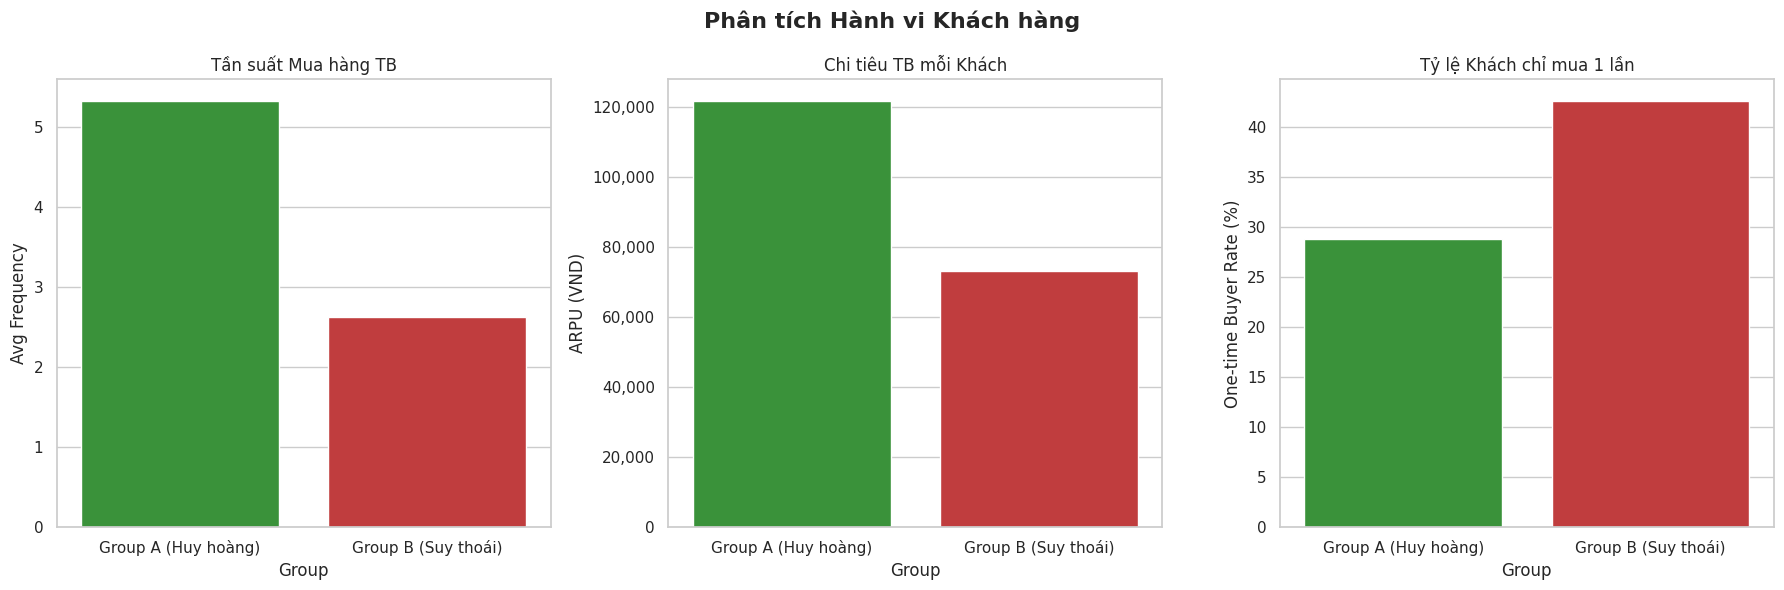

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Cấu hình đường dẫn cho Colab
base_dir = 'data_files'
dir_A = os.path.join(base_dir, "Group_A")
dir_B = os.path.join(base_dir, "Group_B")

def calculate_customer_behavior(group_dir, group_name):
    try:
        # Load data
        orders = pd.read_csv(os.path.join(group_dir, 'orders.csv'))
        payments = pd.read_csv(os.path.join(group_dir, 'payments.csv'))

        # Ghép orders và payments để lấy giá trị thanh toán thực tế
        df_merged = pd.merge(orders, payments, on='order_id', how='inner')

        # Lọc các đơn hàng thành công
        df_valid = df_merged[df_merged['order_status'] != 'cancelled']

        # 2. Phân tích RFM (Tập trung vào Frequency và Monetary)
        rfm = df_valid.groupby('customer_id').agg(
            Frequency=('order_id', 'nunique'),
            Monetary=('payment_value', 'sum')
        ).reset_index()

        # Tính toán chỉ số trung bình toàn tập
        avg_freq = rfm['Frequency'].mean()
        avg_monetary = rfm['Monetary'].mean()

        # Tỷ lệ khách hàng mua 1 lần
        one_time_buyers = (rfm['Frequency'] == 1).sum()
        one_time_buyer_pct = (one_time_buyers / len(rfm)) * 100

        return {
            'Group': group_name,
            'Avg Frequency': avg_freq,
            'ARPU (VND)': avg_monetary,
            'One-time Buyer Rate (%)': one_time_buyer_pct
        }
    except Exception as e:
        print(f"Lỗi: {e}")
        return None

# 3. Thực thi và Trực quan hóa
behavior_A = calculate_customer_behavior(dir_A, 'Group A (Huy hoàng)')
behavior_B = calculate_customer_behavior(dir_B, 'Group B (Suy thoái)')

if behavior_A and behavior_B:
    df_behavior = pd.DataFrame([behavior_A, behavior_B])

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Phân tích Hành vi Khách hàng', fontsize=16, fontweight='bold')

    # Tần suất mua
    sns.barplot(data=df_behavior, x='Group', y='Avg Frequency', ax=axes[0], palette=['#2ca02c', '#d62728'], hue='Group', legend=False)
    axes[0].set_title('Tần suất Mua hàng TB')

    # ARPU
    sns.barplot(data=df_behavior, x='Group', y='ARPU (VND)', ax=axes[1], palette=['#2ca02c', '#d62728'], hue='Group', legend=False)
    axes[1].set_title('Chi tiêu TB mỗi Khách')
    axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y:,.0f}'))

    # One-time buyers
    sns.barplot(data=df_behavior, x='Group', y='One-time Buyer Rate (%)', ax=axes[2], palette=['#2ca02c', '#d62728'], hue='Group', legend=False)
    axes[2].set_title('Tỷ lệ Khách chỉ mua 1 lần')

    plt.tight_layout()
    plt.show()

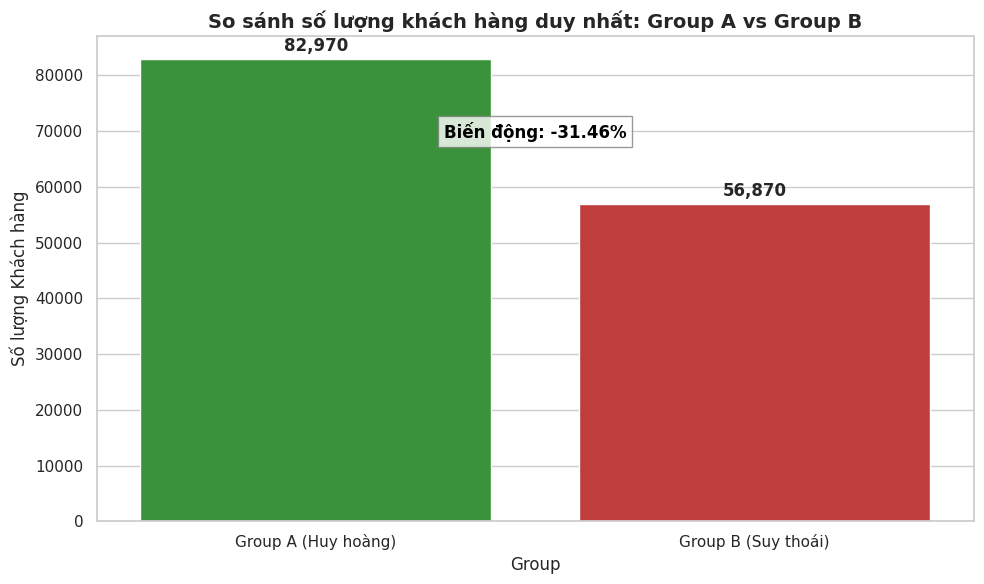

Unique Customers Group A: 82,970
Unique Customers Group B: 56,870
Mức độ sụt giảm khách hàng: -31.46%


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Load order data to identify unique customers
orders_A = pd.read_csv('data_files/Group_A/orders.csv')
orders_B = pd.read_csv('data_files/Group_B/orders.csv')

# 2. Calculate unique customers
unique_cust_A = orders_A['customer_id'].nunique()
unique_cust_B = orders_B['customer_id'].nunique()

# 3. Prepare data for plotting
df_cust_compare = pd.DataFrame({
    'Group': ['Group A (Huy hoàng)', 'Group B (Suy thoái)'],
    'Unique Customers': [unique_cust_A, unique_cust_B]
})

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Colors: Green for Group A, Red for Group B
colors = ['#2ca02c', '#d62728']

ax = sns.barplot(data=df_cust_compare, x='Group', y='Unique Customers', hue='Group', palette=colors, legend=False)

plt.title('So sánh số lượng khách hàng duy nhất: Group A vs Group B', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng Khách hàng', fontsize=12)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontweight='bold')

# Calculate % change
pct_change_cust = ((unique_cust_B - unique_cust_A) / unique_cust_A) * 100

# Add annotation for % change
plt.text(0.5, (unique_cust_A + unique_cust_B)/2, f'Biến động: {pct_change_cust:.2f}%',
         ha='center', va='center', fontsize=12, fontweight='bold', color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"Unique Customers Group A: {unique_cust_A:,.0f}")
print(f"Unique Customers Group B: {unique_cust_B:,.0f}")
print(f"Mức độ sụt giảm khách hàng: {pct_change_cust:.2f}%")

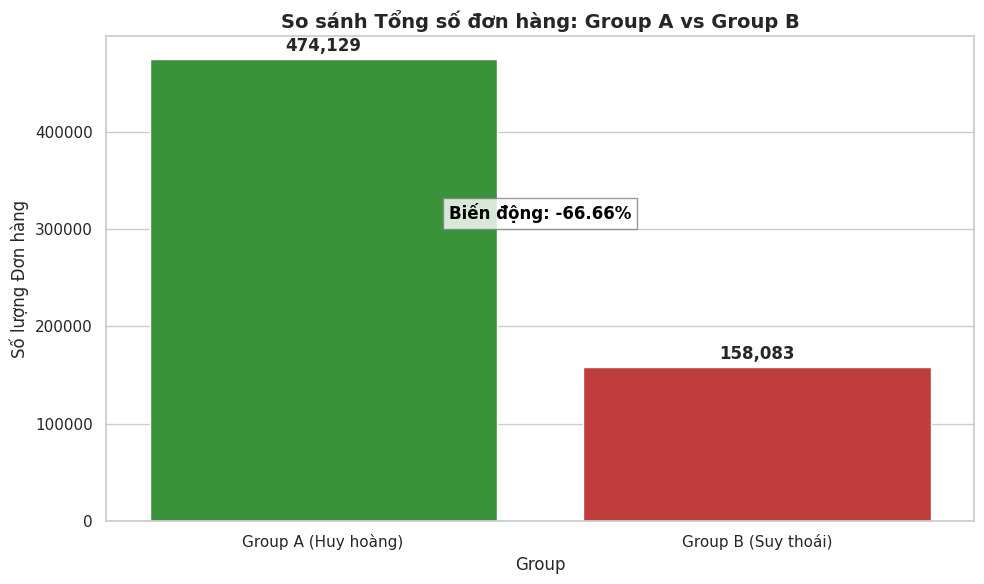

Total Orders Group A: 474,129
Total Orders Group B: 158,083
Mức độ sụt giảm đơn hàng: -66.66%


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Load order data
orders_A = pd.read_csv('data_files/Group_A/orders.csv')
orders_B = pd.read_csv('data_files/Group_B/orders.csv')

# 2. Calculate total orders
total_orders_A = orders_A['order_id'].nunique()
total_orders_B = orders_B['order_id'].nunique()

# 3. Prepare data for plotting
df_orders_compare = pd.DataFrame({
    'Group': ['Group A (Huy hoàng)', 'Group B (Suy thoái)'],
    'Total Orders': [total_orders_A, total_orders_B]
})

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Colors: Green for Group A, Red for Group B
colors = ['#2ca02c', '#d62728']

ax = sns.barplot(data=df_orders_compare, x='Group', y='Total Orders', hue='Group', palette=colors, legend=False)

plt.title('So sánh Tổng số đơn hàng: Group A vs Group B', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng Đơn hàng', fontsize=12)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontweight='bold')

# Calculate % change
pct_change_orders = ((total_orders_B - total_orders_A) / total_orders_A) * 100

# Add annotation for % change
plt.text(0.5, (total_orders_A + total_orders_B)/2, f'Biến động: {pct_change_orders:.2f}%',
         ha='center', va='center', fontsize=12, fontweight='bold', color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"Total Orders Group A: {total_orders_A:,.0f}")
print(f"Total Orders Group B: {total_orders_B:,.0f}")
print(f"Mức độ sụt giảm đơn hàng: {pct_change_orders:.2f}%")

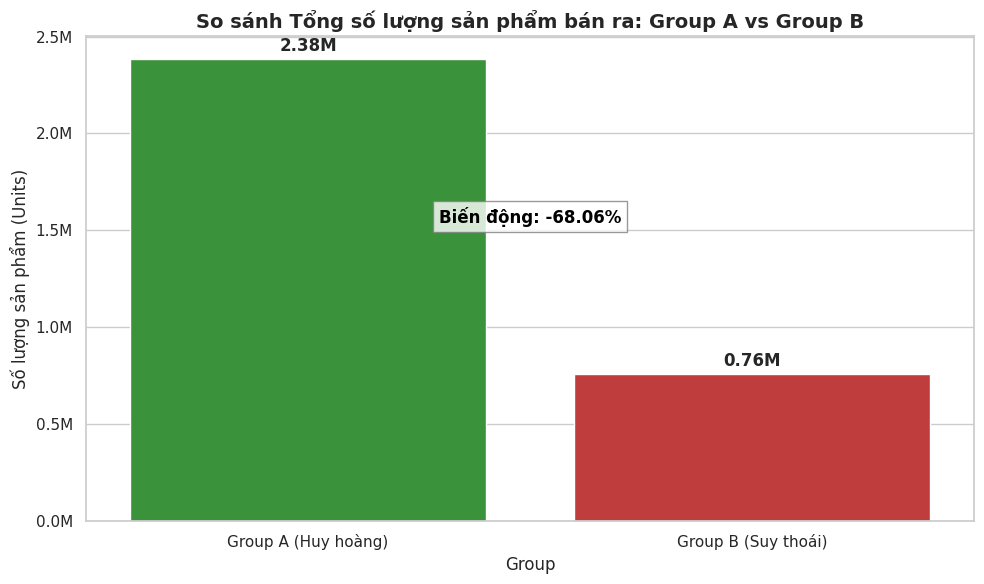

Total Units Sold Group A: 2,381,996
Total Units Sold Group B: 760,734
Mức độ sụt giảm sản lượng: -68.06%


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Load order_items data to calculate units sold
items_A = pd.read_csv('data_files/Group_A/order_items.csv', low_memory=False)
items_B = pd.read_csv('data_files/Group_B/order_items.csv', low_memory=False)

# 2. Calculate total units sold
total_units_A = items_A['quantity'].sum()
total_units_B = items_B['quantity'].sum()

# 3. Prepare data for plotting
df_units_compare = pd.DataFrame({
    'Group': ['Group A (Huy hoàng)', 'Group B (Suy thoái)'],
    'Total Units Sold': [total_units_A, total_units_B]
})

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Colors: Green for Group A, Red for Group B
colors = ['#2ca02c', '#d62728']

ax = sns.barplot(data=df_units_compare, x='Group', y='Total Units Sold', hue='Group', palette=colors, legend=False)

plt.title('So sánh Tổng số lượng sản phẩm bán ra: Group A vs Group B', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng sản phẩm (Units)', fontsize=12)

# Format y-axis to show millions
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

# Add labels on top of bars
for container in ax.containers:
    labels = [f'{v.get_height()/1e6:,.2f}M' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontweight='bold')

# Calculate % change
pct_change_units = ((total_units_B - total_units_A) / total_units_A) * 100

# Add annotation for % change
plt.text(0.5, (total_units_A + total_units_B)/2, f'Biến động: {pct_change_units:.2f}%',
         ha='center', va='center', fontsize=12, fontweight='bold', color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"Total Units Sold Group A: {total_units_A:,.0f}")
print(f"Total Units Sold Group B: {total_units_B:,.0f}")
print(f"Mức độ sụt giảm sản lượng: {pct_change_units:.2f}%")

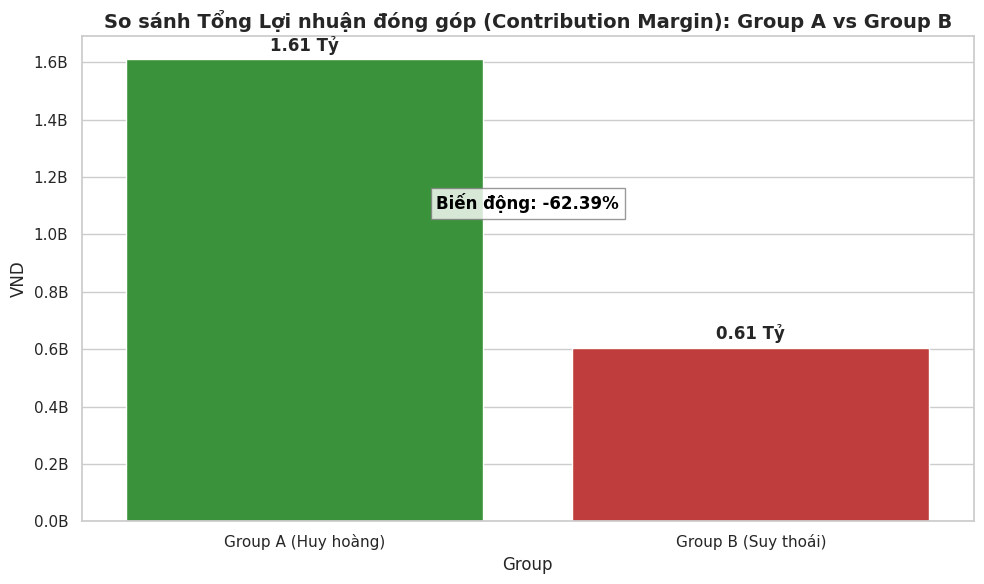

Total Margin Group A: 1,610,484,972 VND
Total Margin Group B: 605,754,108 VND
Mức độ sụt giảm lợi nhuận: -62.39%


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Load sales data
sales_A = pd.read_csv('data_files/Group_A/sales.csv')
sales_B = pd.read_csv('data_files/Group_B/sales.csv')

# 2. Calculate Total Contribution Margin (Revenue - COGS)
# Note: In our data context, Contribution Margin is derived from Revenue and COGS in the sales files
margin_A = (sales_A['Revenue'] - sales_A['COGS']).sum()
margin_B = (sales_B['Revenue'] - sales_B['COGS']).sum()

# 3. Prepare data for plotting
df_margin_compare = pd.DataFrame({
    'Group': ['Group A (Huy hoàng)', 'Group B (Suy thoái)'],
    'Total Contribution Margin': [margin_A, margin_B]
})

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Colors: Green for Group A, Red for Group B
colors = ['#2ca02c', '#d62728']

ax = sns.barplot(data=df_margin_compare, x='Group', y='Total Contribution Margin', hue='Group', palette=colors, legend=False)

plt.title('So sánh Tổng Lợi nhuận đóng góp (Contribution Margin): Group A vs Group B', fontsize=14, fontweight='bold')
plt.ylabel('VND', fontsize=12)

# Format y-axis to show Billions (Tỷ)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e9:,.1f}B'))

# Add labels on top of bars
for container in ax.containers:
    labels = [f'{v.get_height()/1e9:,.2f} Tỷ' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontweight='bold')

# Calculate % change
pct_change_margin = ((margin_B - margin_A) / margin_A) * 100

# Add annotation for % change
plt.text(0.5, (margin_A + margin_B)/2, f'Biến động: {pct_change_margin:.2f}%',
         ha='center', va='center', fontsize=12, fontweight='bold', color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"Total Margin Group A: {margin_A:,.0f} VND")
print(f"Total Margin Group B: {margin_B:,.0f} VND")
print(f"Mức độ sụt giảm lợi nhuận: {pct_change_margin:.2f}%")

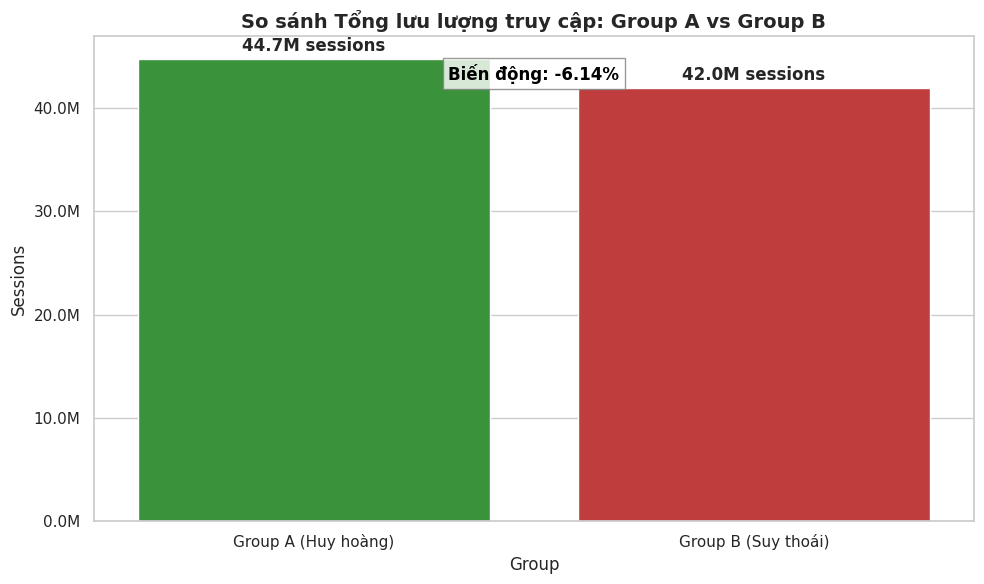

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Load traffic data
traffic_A = pd.read_csv('data_files/Group_A/web_traffic.csv')
traffic_B = pd.read_csv('data_files/Group_B/web_traffic.csv')

# 2. Calculate totals
total_sessions_A = traffic_A['sessions'].sum()
total_sessions_B = traffic_B['sessions'].sum()

# 3. Prepare data for comparison
df_compare = pd.DataFrame({
    'Group': ['Group A (Huy hoàng)', 'Group B (Suy thoái)'],
    'Total Sessions': [total_sessions_A, total_sessions_B]
})

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Using Green for A (Growth) and Red for B (Decline) as per context
colors = ['#2ca02c', '#d62728']

ax = sns.barplot(data=df_compare, x='Group', y='Total Sessions', hue='Group', palette=colors, legend=False)

plt.title('So sánh Tổng lưu lượng truy cập: Group A vs Group B', fontsize=14, fontweight='bold')
plt.ylabel('Sessions', fontsize=12)

# Format y-axis to show millions
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

# Add labels on top of bars
for container in ax.containers:
    labels = [f'{v.get_height()/1e6:,.1f}M sessions' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontweight='bold')

# Add annotation for % change
pct_change = ((total_sessions_B - total_sessions_A) / total_sessions_A) * 100
plt.text(0.5, (total_sessions_A + total_sessions_B)/2, f'Biến động: {pct_change:.2f}%',
         ha='center', va='center', fontsize=12, fontweight='bold', color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

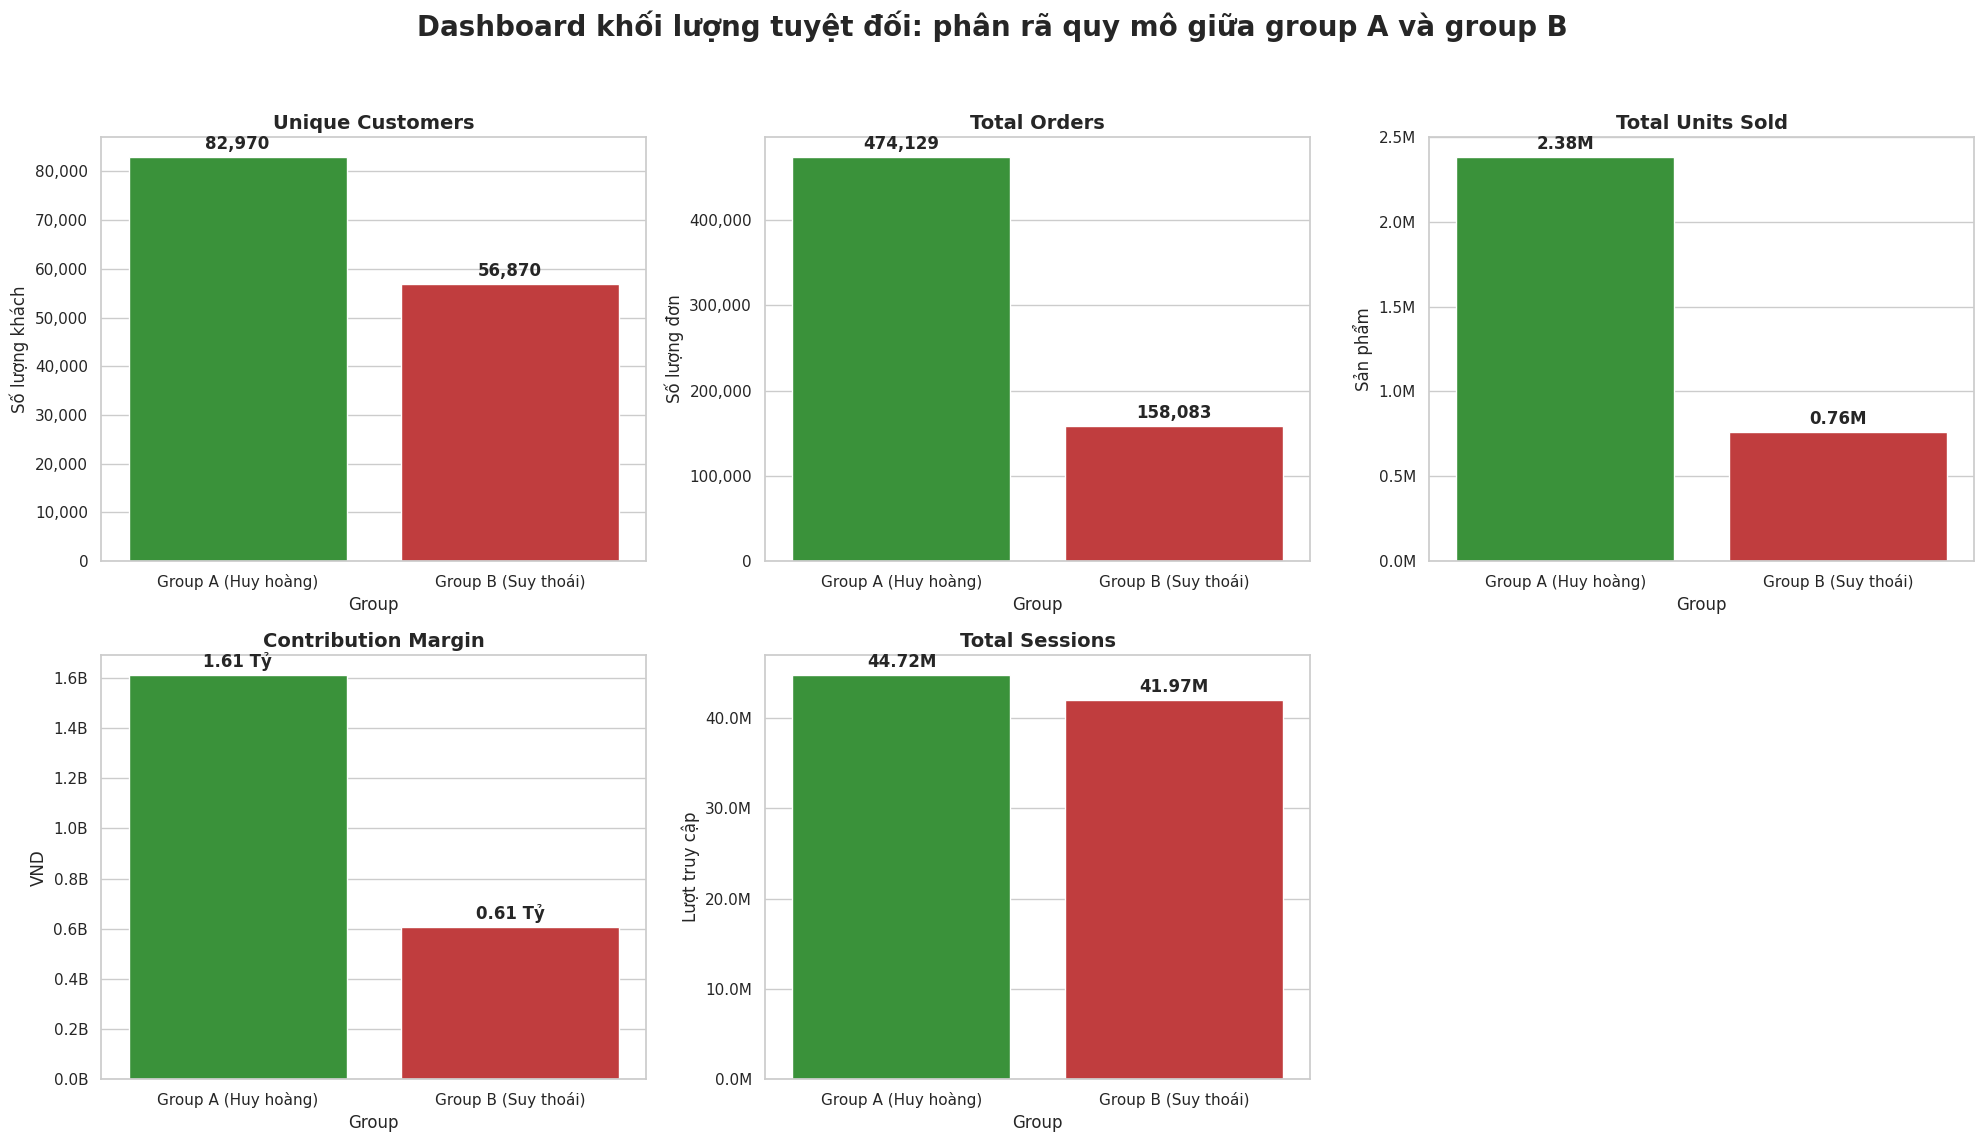

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Load data functions
def get_absolute_metrics():
    base_dir = 'data_files'
    results = []
    for g_id, g_name in [('Group_A', 'Group A (Huy hoàng)'), ('Group_B', 'Group B (Suy thoái)')]:
        path = os.path.join(base_dir, g_id)
        orders = pd.read_csv(os.path.join(path, 'orders.csv'))
        items = pd.read_csv(os.path.join(path, 'order_items.csv'), low_memory=False)
        sales = pd.read_csv(os.path.join(path, 'sales.csv'))
        traffic = pd.read_csv(os.path.join(path, 'web_traffic.csv'))

        results.append({
            'Group': g_name,
            'Unique Customers': orders['customer_id'].nunique(),
            'Total Orders': orders['order_id'].nunique(),
            'Total Units Sold': items['quantity'].sum(),
            'Contribution Margin': (sales['Revenue'] - sales['COGS']).sum(),
            'Total Sessions': traffic['sessions'].sum()
        })
    return pd.DataFrame(results)

# 2. Process and Plot
df_dashboard = get_absolute_metrics()
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dashboard khối lượng tuyệt đối: phân rã quy mô giữa group A và group B', fontsize=20, fontweight='bold', y=0.98)

metrics_cfg = [
    ('Unique Customers', 'Số lượng khách', axes[0,0], '{:,.0f}'),
    ('Total Orders', 'Số lượng đơn', axes[0,1], '{:,.0f}'),
    ('Total Units Sold', 'Sản phẩm', axes[0,2], '{:,.1f}M'),
    ('Contribution Margin', 'VND', axes[1,0], '{:,.1f}B'),
    ('Total Sessions', 'Lượt truy cập', axes[1,1], '{:,.1f}M')
]

colors = ['#2ca02c', '#d62728']

for i, (col, ylabel, ax, fmt) in enumerate(metrics_cfg):
    sns.barplot(data=df_dashboard, x='Group', y=col, hue='Group', ax=ax, palette=colors, legend=False)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel)

    # Custom formatting for y-axis and labels
    if 'M' in fmt:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))
    elif 'B' in fmt:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e9:,.1f}B'))
    else:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

    for container in ax.containers:
        val = container.datavalues
        if 'M' in fmt: labels = [f'{v/1e6:,.2f}M' for v in val]
        elif 'B' in fmt: labels = [f'{v/1e9:,.2f} Tỷ' for v in val]
        else: labels = [f'{v:,.0f}' for v in val]
        ax.bar_label(container, labels=labels, padding=3, fontweight='bold')

# Remove empty plot
fig.delaxes(axes[1,2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

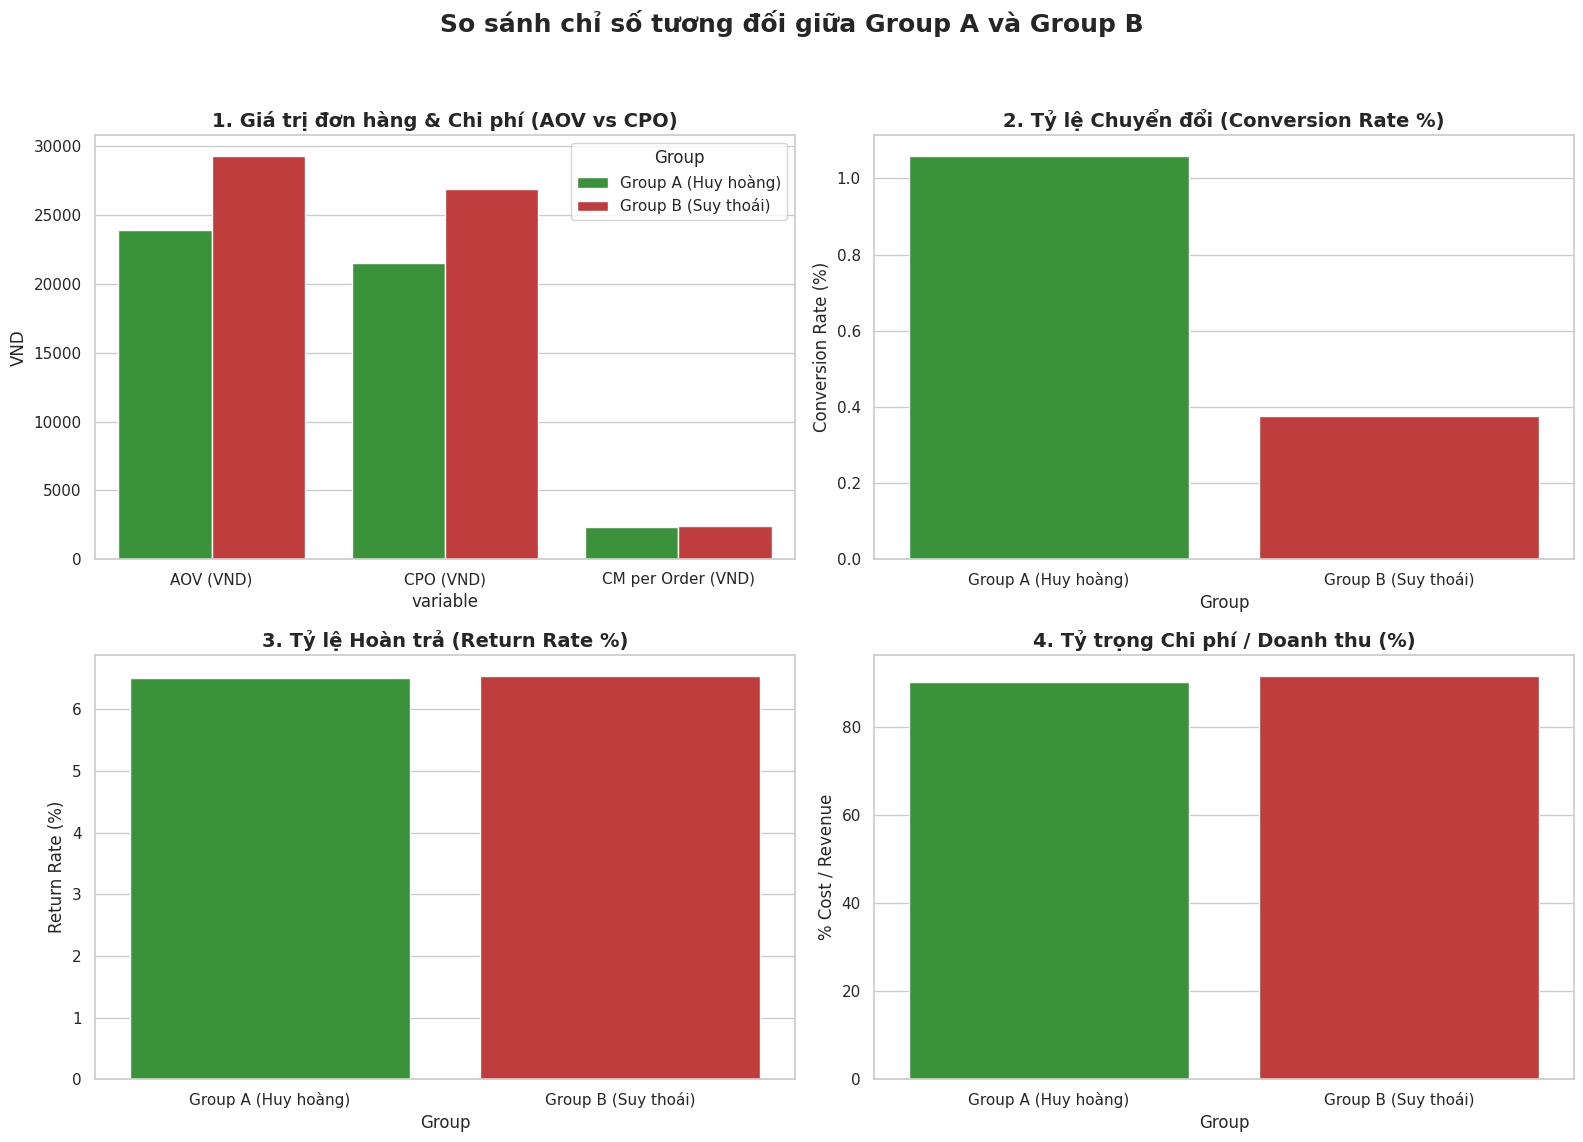

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.ticker as ticker

# 1. Configuration for Colab Environment
base_dir = 'data_files'
dir_A = os.path.join(base_dir, 'Group_A')
dir_B = os.path.join(base_dir, 'Group_B')

def calculate_relative_metrics(group_dir, group_name):
    # Required files for this analysis
    required_files = ['orders.csv', 'sales.csv', 'order_items.csv', 'web_traffic.csv', 'returns.csv']

    # Check if directory and files exist
    if not os.path.exists(group_dir):
        print(f"Error: Directory {group_dir} does not exist.")
        return None

    for f in required_files:
        if not os.path.exists(os.path.join(group_dir, f)):
            print(f"Error: Missing file {f} in {group_dir}")
            return None

    try:
        orders = pd.read_csv(os.path.join(group_dir, 'orders.csv'))
        sales = pd.read_csv(os.path.join(group_dir, 'sales.csv'))
        order_items = pd.read_csv(os.path.join(group_dir, 'order_items.csv'), low_memory=False)
        traffic = pd.read_csv(os.path.join(group_dir, 'web_traffic.csv'))
        returns = pd.read_csv(os.path.join(group_dir, 'returns.csv'))

        total_orders = orders['order_id'].nunique()
        total_revenue = sales['Revenue'].sum()
        total_cogs = sales['COGS'].sum()
        total_discount = order_items['discount_amount'].sum()
        total_sessions = traffic['sessions'].sum()

        delivered_orders = orders[orders['order_status'].isin(['delivered', 'returned'])]['order_id'].nunique()
        returned_orders = returns['order_id'].nunique()

        aov = total_revenue / total_orders if total_orders > 0 else 0
        cpo = (total_cogs + total_discount) / total_orders if total_orders > 0 else 0
        cm_per_order = aov - cpo
        cr = (total_orders / total_sessions) * 100 if total_sessions > 0 else 0
        return_rate = (returned_orders / delivered_orders) * 100 if delivered_orders > 0 else 0

        return {
            'Group': group_name,
            'AOV (VND)': aov,
            'CPO (VND)': cpo,
            'CM per Order (VND)': cm_per_order,
            'Conversion Rate (%)': cr,
            'Return Rate (%)': return_rate
        }
    except Exception as e:
        print(f'Error calculating metrics for {group_name}: {e}')
        return None

metrics_A = calculate_relative_metrics(dir_A, 'Group A (Huy hoàng)')
metrics_B = calculate_relative_metrics(dir_B, 'Group B (Suy thoái)')

if metrics_A and metrics_B:
    df_metrics = pd.DataFrame([metrics_A, metrics_B])
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('So sánh chỉ số tương đối giữa Group A và Group B', fontsize=18, fontweight='bold')

    df_melted = df_metrics.melt(id_vars='Group', value_vars=['AOV (VND)', 'CPO (VND)', 'CM per Order (VND)'])
    sns.barplot(data=df_melted, x='variable', y='value', hue='Group', ax=axes[0, 0], palette=['#2ca02c', '#d62728'])
    axes[0, 0].set_title('1. Giá trị đơn hàng & Chi phí (AOV vs CPO)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('VND')

    sns.barplot(data=df_metrics, x='Group', y='Conversion Rate (%)', hue='Group', ax=axes[0, 1], palette=['#2ca02c', '#d62728'], legend=False)
    axes[0, 1].set_title('2. Tỷ lệ Chuyển đổi (Conversion Rate %)', fontsize=14, fontweight='bold')

    sns.barplot(data=df_metrics, x='Group', y='Return Rate (%)', hue='Group', ax=axes[1, 0], palette=['#2ca02c', '#d62728'], legend=False)
    axes[1, 0].set_title('3. Tỷ lệ Hoàn trả (Return Rate %)', fontsize=14, fontweight='bold')

    df_metrics['% Cost / Revenue'] = (df_metrics['CPO (VND)'] / df_metrics['AOV (VND)']) * 100
    sns.barplot(data=df_metrics, x='Group', y='% Cost / Revenue', hue='Group', ax=axes[1, 1], palette=['#2ca02c', '#d62728'], legend=False)
    axes[1, 1].set_title('4. Tỷ trọng Chi phí / Doanh thu (%)', fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Dashboard cannot be generated. Please upload all required CSV files to Group_A and Group_B folders.")

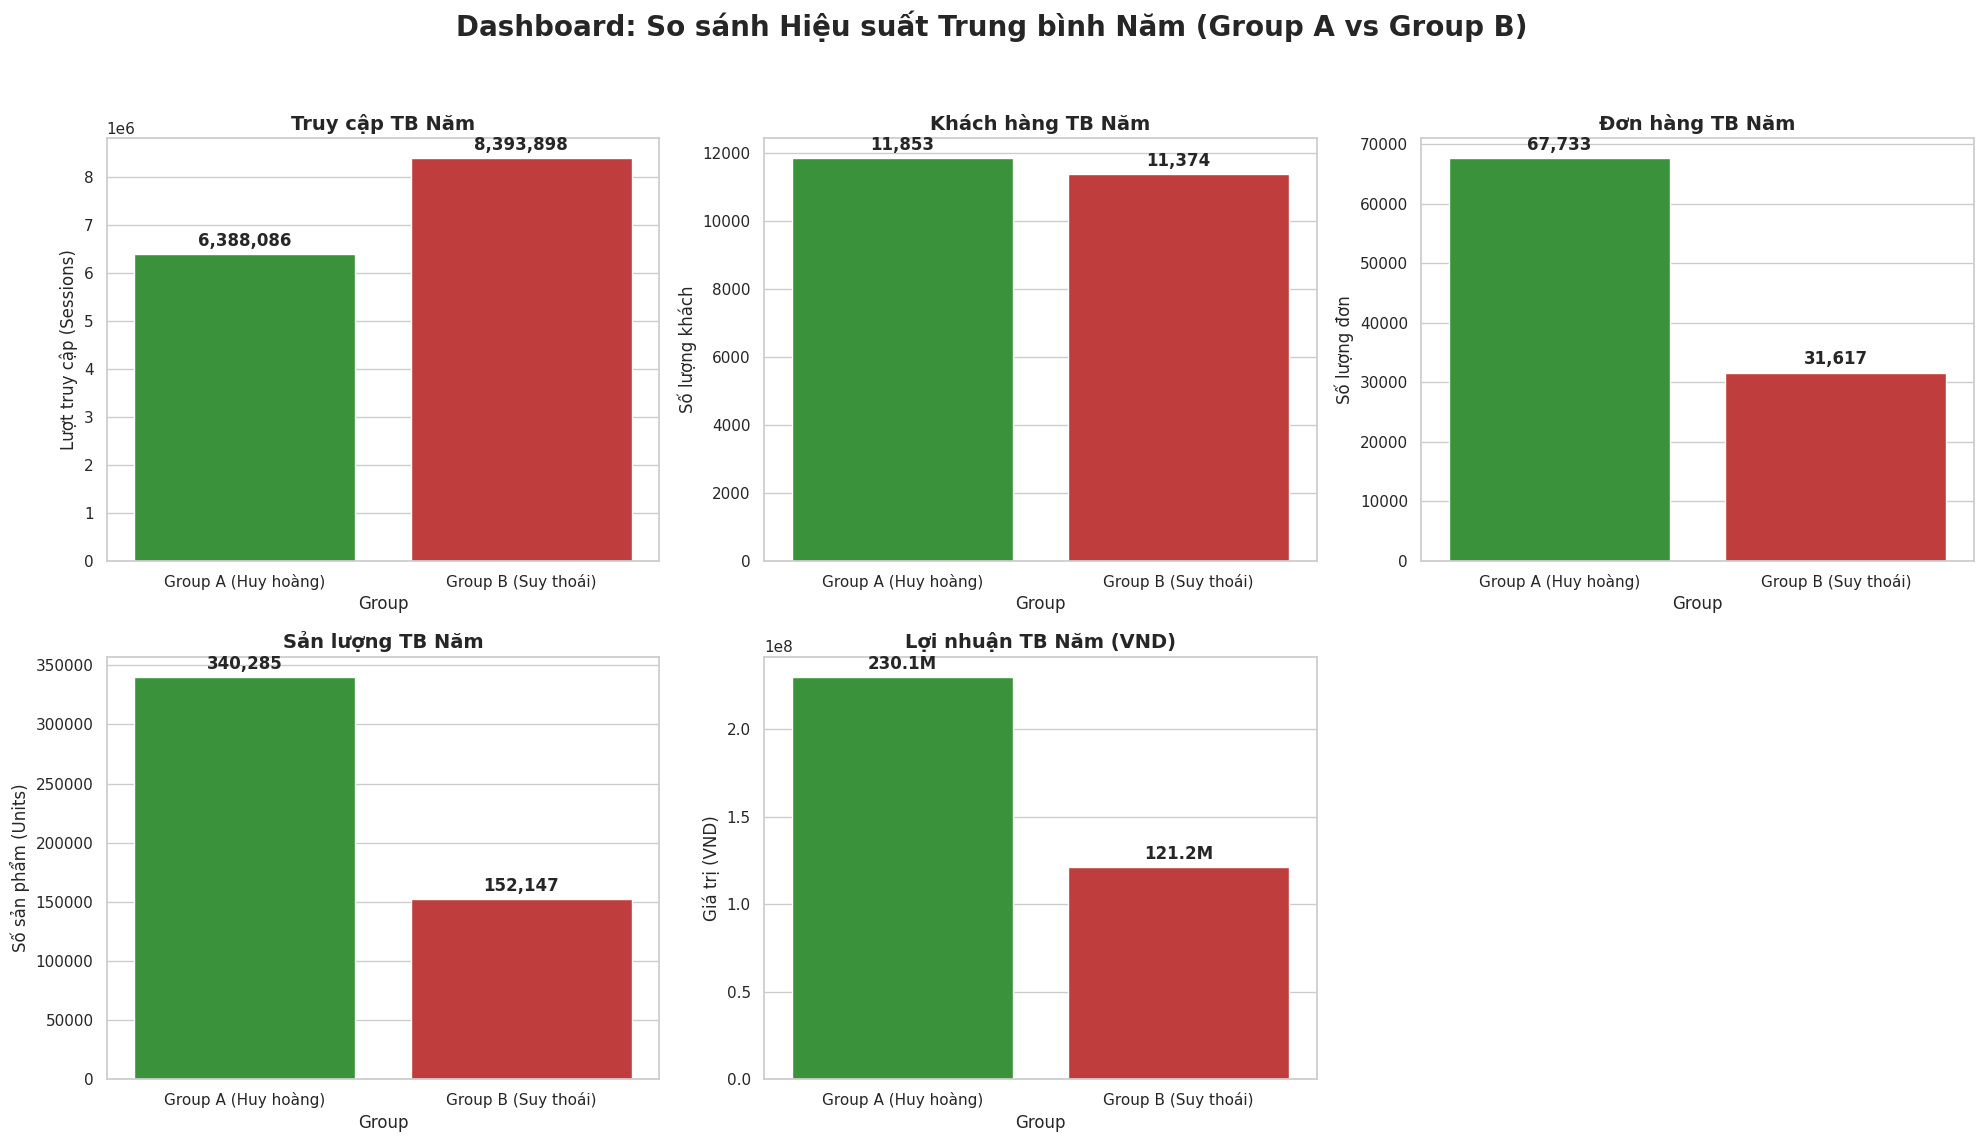

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def get_annual_metrics(group_dir, group_name):
    # Load data
    orders = pd.read_csv(os.path.join(group_dir, 'orders.csv'))
    sales = pd.read_csv(os.path.join(group_dir, 'sales.csv'))
    items = pd.read_csv(os.path.join(group_dir, 'order_items.csv'), low_memory=False)
    traffic = pd.read_csv(os.path.join(group_dir, 'web_traffic.csv'))

    # Determine number of years
    orders['order_date'] = pd.to_datetime(orders['order_date'])
    years_count = orders['order_date'].dt.year.nunique()
    if years_count == 0: years_count = 1

    # Calculate Totals
    total_traffic = traffic['sessions'].sum()
    total_customers = orders['customer_id'].nunique()
    total_orders = orders['order_id'].nunique()
    total_units = items['quantity'].sum()
    total_cm = (sales['Revenue'] - sales['COGS']).sum()

    return {
        'Group': group_name,
        'Truy cập TB Năm': total_traffic / years_count,
        'Khách hàng TB Năm': total_customers / years_count,
        'Đơn hàng TB Năm': total_orders / years_count,
        'Sản lượng TB Năm': total_units / years_count,
        'Lợi nhuận TB Năm (VND)': total_cm / years_count
    }

# Calculate for both groups
annual_A = get_annual_metrics('data_files/Group_A', 'Group A (Huy hoàng)')
annual_B = get_annual_metrics('data_files/Group_B', 'Group B (Suy thoái)')

df_annual = pd.DataFrame([annual_A, annual_B])

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dashboard: So sánh Hiệu suất Trung bình Năm (Group A vs Group B)', fontsize=20, fontweight='bold')

metrics = [
    ('Truy cập TB Năm', 'Lượt truy cập (Sessions)', axes[0,0]),
    ('Khách hàng TB Năm', 'Số lượng khách', axes[0,1]),
    ('Đơn hàng TB Năm', 'Số lượng đơn', axes[0,2]),
    ('Sản lượng TB Năm', 'Số sản phẩm (Units)', axes[1,0]),
    ('Lợi nhuận TB Năm (VND)', 'Giá trị (VND)', axes[1,1])
]

for col, label, ax in metrics:
    sns.barplot(data=df_annual, x='Group', y=col, hue='Group', ax=ax, palette=['#2ca02c', '#d62728'], legend=False)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.set_ylabel(label)

    # Format labels
    for container in ax.containers:
        if 'VND' in col:
            labels = [f'{v.get_height()/1e6:,.1f}M' for v in container]
        else:
            labels = [f'{v.get_height():,.0f}' for v in container]
        ax.bar_label(container, labels=labels, padding=3, fontweight='bold')

# Remove empty subplot
fig.delaxes(axes[1,2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

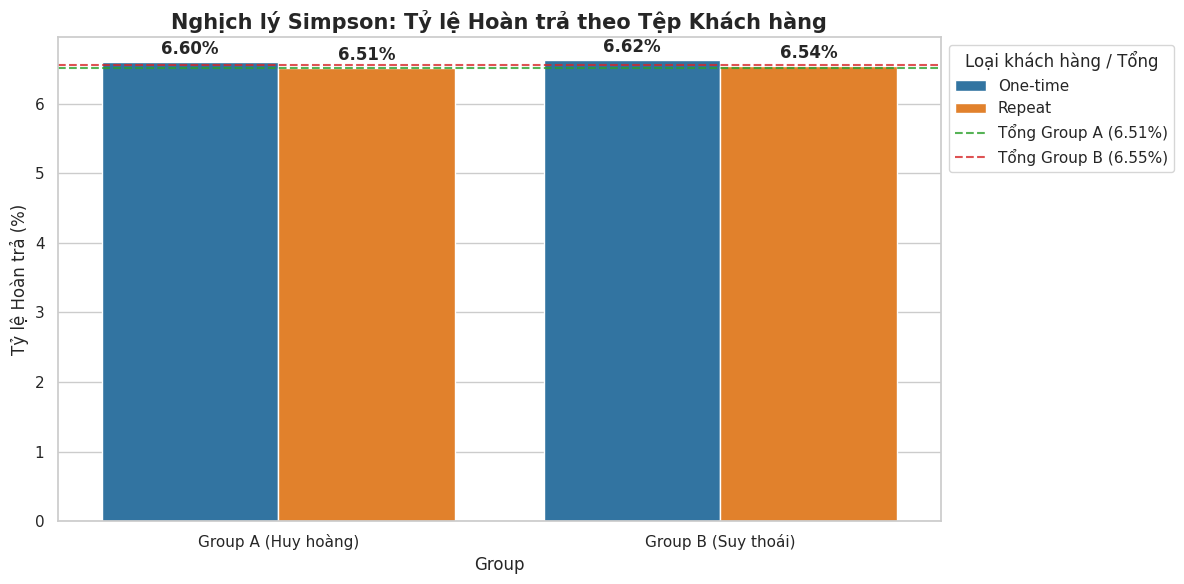

--- So sánh Tổng quan ---
Tỷ lệ hoàn trả tổng Group A: 6.5126%
Tỷ lệ hoàn trả tổng Group B: 6.5512%

--- Chi tiết theo Phân khúc ---


,Group,Buyer_Type,Return_Rate
0,Group A (Huy hoàng),One-time,6.596679
1,Group A (Huy hoàng),Repeat,6.508322
0,Group B (Suy thoái),One-time,6.621881
1,Group B (Suy thoái),Repeat,6.538941


In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

def get_return_behavior(group_dir, group_name):
    # Load data
    orders = pd.read_csv(os.path.join(group_dir, 'orders.csv'))
    returns = pd.read_csv(os.path.join(group_dir, 'returns.csv'))

    # Identify delivered or returned orders (base for return rate)
    valid_orders = orders[orders['order_status'].isin(['delivered', 'returned'])].copy()

    # Identify returned order IDs
    returned_ids = set(returns['order_id'])
    valid_orders['is_returned'] = valid_orders['order_id'].apply(lambda x: 1 if x in returned_ids else 0)

    # Segment customers by Frequency within this group
    cust_freq = orders.groupby('customer_id')['order_id'].nunique().reset_index()
    cust_freq['Buyer_Type'] = cust_freq['order_id'].apply(lambda x: 'One-time' if x == 1 else 'Repeat')

    # Merge segments back to valid orders
    df_analysis = pd.merge(valid_orders[['order_id', 'customer_id', 'is_returned']],
                           cust_freq[['customer_id', 'Buyer_Type']],
                           on='customer_id', how='left')

    # Calculate return rate by segment
    stats = df_analysis.groupby('Buyer_Type')['is_returned'].agg(['sum', 'count']).reset_index()
    stats['Return_Rate'] = (stats['sum'] / stats['count']) * 100
    stats['Group'] = group_name

    # Total return rate for the group
    total_rr = (df_analysis['is_returned'].sum() / len(df_analysis)) * 100

    return stats, total_rr

# Execute analysis
stats_A, total_A = get_return_behavior('data_files/Group_A', 'Group A (Huy hoàng)')
stats_B, total_B = get_return_behavior('data_files/Group_B', 'Group B (Suy thoái)')

# Combine data
df_simpson = pd.concat([stats_A, stats_B])

# Visualization
plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')
ax = sns.barplot(data=df_simpson, x='Group', y='Return_Rate', hue='Buyer_Type', palette=['#1f77b4', '#ff7f0e'])

plt.title("Nghịch lý Simpson: Tỷ lệ Hoàn trả theo Tệp Khách hàng", fontsize=15, fontweight='bold')
plt.ylabel("Tỷ lệ Hoàn trả (%)")

# Add line for Total Return Rate
plt.axhline(y=total_A, color='#2ca02c', linestyle='--', alpha=0.8, label=f'Tổng Group A ({total_A:.2f}%)')
plt.axhline(y=total_B, color='#d62728', linestyle='--', alpha=0.8, label=f'Tổng Group B ({total_B:.2f}%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontweight='bold')

plt.legend(title='Loại khách hàng / Tổng', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print(f"--- So sánh Tổng quan ---")
print(f"Tỷ lệ hoàn trả tổng Group A: {total_A:.4f}%")
print(f"Tỷ lệ hoàn trả tổng Group B: {total_B:.4f}%")
print("\n--- Chi tiết theo Phân khúc ---")
display(df_simpson[['Group', 'Buyer_Type', 'Return_Rate']])

Đang xử lý dữ liệu cho Group A và Group B...


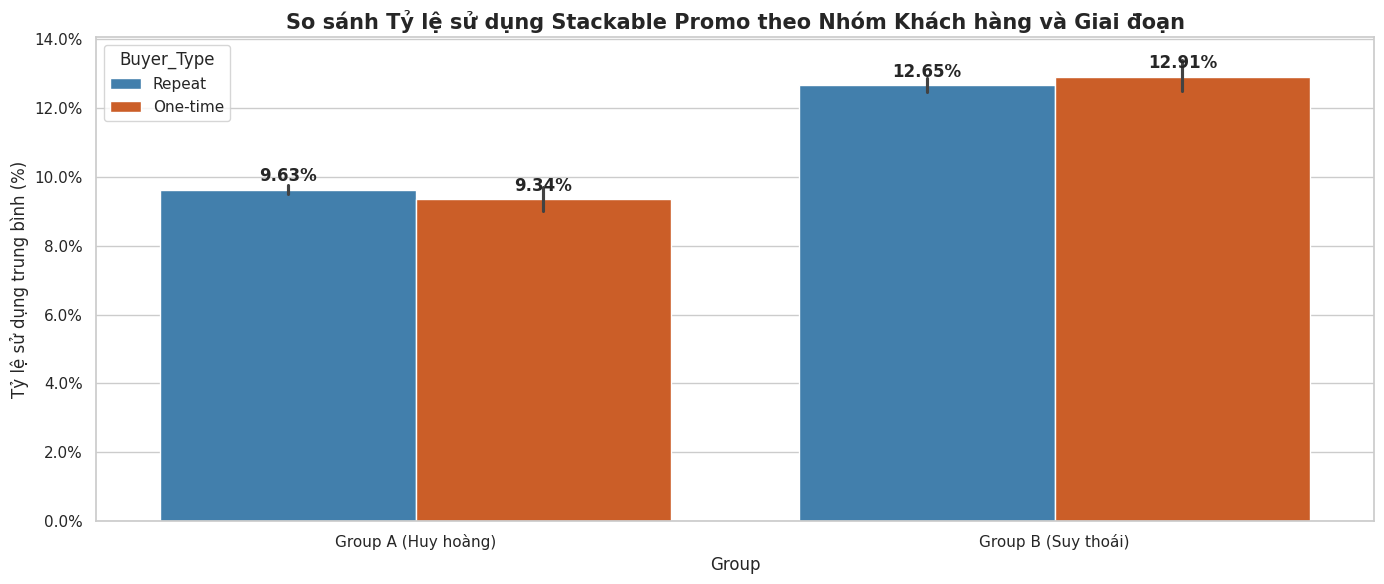

--- Group A (Huy hoàng) ---
Mann-Whitney U p-value: 0.0000
One-time Avg: 9.3435%, Repeat Avg: 9.6271%

--- Group B (Suy thoái) ---
Mann-Whitney U p-value: 0.0000
One-time Avg: 12.9100%, Repeat Avg: 12.6547%



In [ ]:
import pandas as pd
import os
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def analyze_promo_behavior(group_dir, group_name):
    # Load datasets
    orders = pd.read_csv(os.path.join(group_dir, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(group_dir, 'order_items.csv'), low_memory=False)
    promotions = pd.read_csv(os.path.join(group_dir, 'promotions.csv'))

    # Map stackable flags
    promo_dict = dict(zip(promotions['promo_id'], promotions['stackable_flag']))

    # Check if promos used in order items were stackable
    order_items['is_stackable'] = ((order_items['promo_id'].map(promo_dict).fillna(0) == 1) |
                                   (order_items['promo_id_2'].map(promo_dict).fillna(0) == 1)).astype(int)

    # Aggregate to order level
    order_promo = order_items.groupby('order_id')['is_stackable'].max().reset_index()

    # Merge with orders to get customer IDs
    df_merged = pd.merge(orders[['order_id', 'customer_id']], order_promo, on='order_id', how='left').fillna(0)

    # Aggregate to customer level
    cust_behavior = df_merged.groupby('customer_id').agg(
        Frequency=('order_id', 'nunique'),
        Stackable_Usage_Rate=('is_stackable', 'mean')
    ).reset_index()

    cust_behavior['Buyer_Type'] = cust_behavior['Frequency'].apply(lambda x: 'One-time' if x == 1 else 'Repeat')
    cust_behavior['Group'] = group_name

    return cust_behavior

# Analyze both groups
print("Đang xử lý dữ liệu cho Group A và Group B...")
data_A = analyze_promo_behavior('data_files/Group_A', 'Group A (Huy hoàng)')
data_B = analyze_promo_behavior('data_files/Group_B', 'Group B (Suy thoái)')

# Combine for visualization
df_combined = pd.concat([data_A, data_B])

# Visualization
plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')
ax = sns.barplot(data=df_combined, x='Group', y='Stackable_Usage_Rate', hue='Buyer_Type', palette=['#3182bd', '#e6550d'])

plt.title('So sánh Tỷ lệ sử dụng Stackable Promo theo Nhóm Khách hàng và Giai đoạn', fontsize=15, fontweight='bold')
plt.ylabel('Tỷ lệ sử dụng trung bình (%)', fontsize=12)

# Format Y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for container in ax.containers:
    # Format labels as percentages
    labels = [f'{v.get_height():.2%}' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical Testing
for g_name in ['Group A (Huy hoàng)', 'Group B (Suy thoái)']:
    subset = df_combined[df_combined['Group'] == g_name]
    ot = subset[subset['Buyer_Type'] == 'One-time']['Stackable_Usage_Rate']
    rp = subset[subset['Buyer_Type'] == 'Repeat']['Stackable_Usage_Rate']
    u, p = mannwhitneyu(ot, rp)
    print(f"--- {g_name} ---")
    print(f"Mann-Whitney U p-value: {p:.4f}")
    print(f"One-time Avg: {ot.mean():.4%}, Repeat Avg: {rp.mean():.4%}\n")